In [1]:
import kymatio
print("kymatio:", getattr(kymatio, "__version__", "unknown"))
print("kymatio path:", kymatio.__file__)

kymatio: 0.4.0.dev0
kymatio path: /Users/amasaryk/projects/ssqueeze/kymatio/kymatio/__init__.py


In [2]:
import tensorflow as tf
from kymatio.tensorflow import Scattering1D

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

sc = Scattering1D(J=6, shape=4096)  # shape is signal length
x = tf.random.normal([4, 4096])
y = sc(x)

print("output shape:", y.shape)
# Where is y?
print("y device:", y.device)

TF: 2.18.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-02-26 09:37:45.835368: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-02-26 09:37:45.835532: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-26 09:37:45.835538: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1772120265.835883 1834098 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1772120265.836194 1834098 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


output shape: (4, 26, 64)
y device: /job:localhost/replica:0/task:0/device:GPU:0


In [3]:
import tensorflow as tf
from kymatio.tensorflow import Scattering2D
sc = Scattering2D(J=2, shape=(64, 64))
x = tf.random.normal([2, 64, 64])
y = sc(x)

In [4]:
import tensorflow as tf
from kymatio.tensorflow import Scattering2D
sc = Scattering2D(J=2, shape=(64, 64))
x = tf.random.normal([2, 64, 64])
y = sc(x)

In [5]:
import inspect
from kymatio.tensorflow import Scattering1D as TFScat1D
from kymatio.torch import Scattering1D as TorchScat1D

print("TF Scattering1D file:", inspect.getfile(TFScat1D))
print("Torch Scattering1D file:", inspect.getfile(TorchScat1D))

TF Scattering1D file: /Users/amasaryk/projects/ssqueeze/kymatio/kymatio/tensorflow.py
Torch Scattering1D file: /Users/amasaryk/projects/ssqueeze/kymatio/kymatio/torch.py


In [5]:
from kymatio.frontend.base_frontend import ScatteringBase
from kymatio.frontend.numpy_frontend import ScatteringNumPy
from kymatio.frontend.torch_frontend import ScatteringTorch
from kymatio.frontend.tensorflow_frontend import ScatteringTensorFlow

print("Base + frontend mixins imported OK")
print("ScatteringBase:", ScatteringBase)
print("ScatteringNumPy:", ScatteringNumPy)
print("ScatteringTorch:", ScatteringTorch)
print("ScatteringTensorFlow:", ScatteringTensorFlow)

/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


Base + frontend mixins imported OK
ScatteringBase: <class 'kymatio.frontend.base_frontend.ScatteringBase'>
ScatteringNumPy: <class 'kymatio.frontend.numpy_frontend.ScatteringNumPy'>
ScatteringTorch: <class 'kymatio.frontend.torch_frontend.ScatteringTorch'>
ScatteringTensorFlow: <class 'kymatio.frontend.tensorflow_frontend.ScatteringTensorFlow'>


In [7]:
import tensorflow as tf
from kymatio.tensorflow import Scattering1D

print("TF GPUs:", tf.config.list_physical_devices("GPU"))

sc = Scattering1D(J=6, shape=4096)
x = tf.random.normal([4, 4096])
y = sc(x)

print("TF ok:", y.shape, y.dtype.name)
print("device:", y.device)

TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF ok: (4, 26, 64) float32
device: /job:localhost/replica:0/task:0/device:GPU:0


In [8]:
import torch
from kymatio.torch import Scattering1D

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
sc = Scattering1D(J=6, shape=4096).to(device)
x = torch.randn(4, 4096, device=device)
y = sc(x)

print("Torch ok:", tuple(y.shape), y.dtype, type(y))
print("device:", y.device)

Torch ok: (4, 26, 64) torch.float32 <class 'torch.Tensor'>
device: mps:0


In [9]:
import inspect
from kymatio.numpy import Scattering1D as N1D
from kymatio.tensorflow import Scattering1D as TF1D
from kymatio.torch import Scattering1D as T1D

print("NumPy Scattering1D defined in:", inspect.getfile(N1D))
print("TF Scattering1D defined in:", inspect.getfile(TF1D))
print("Torch Scattering1D defined in:", inspect.getfile(T1D))

NumPy Scattering1D defined in: /Users/amasaryk/projects/ssqueeze/kymatio/kymatio/numpy.py
TF Scattering1D defined in: /Users/amasaryk/projects/ssqueeze/kymatio/kymatio/tensorflow.py
Torch Scattering1D defined in: /Users/amasaryk/projects/ssqueeze/kymatio/kymatio/torch.py


In [6]:
%cd ~/projects/ssqueeze/kymatio

/Users/amasaryk/projects/ssqueeze/kymatio


In [7]:
import os
print("\n".join(sorted(os.listdir("examples/1d"))))

README.txt
classif_keras.py
plot_classif_torch.py
plot_filters.py
plot_real_signal.py
plot_synthetic.py
reconstruct_torch.py


In [8]:
%run examples/1d/classif_keras.py

/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/deeplake/util/check_latest_version.py:32: UserWarning: A newer version of deeplake (4.5.3) is available. It's recommended that you update to the latest version using `pip install -U deeplake`.
  warnings.warn(


Opening dataset in read-only mode as you don't have write permissions.


2026-02-26 10:34:28.546810: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-02-26 10:34:28.546832: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-26 10:34:28.546837: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1772123668.547108 1912504 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1772123668.547318 1912504 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scattering1d (Scattering1D)     │ (None, 337, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 336, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 336, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 336)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 336)            │         1,344 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         3,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 4,042 (15.79 KB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/50


2026-02-26 10:34:35.433510: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.2569 - loss: 3.0893 - val_accuracy: 0.0000e+00 - val_loss: 25.7205
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 483ms/step - accuracy: 0.2986 - loss: 2.6687 - val_accuracy: 0.0000e+00 - val_loss: 12.9925
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 449ms/step - accuracy: 0.2292 - loss: 2.4138 - val_accuracy: 0.0000e+00 - val_loss: 5.4184
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 450ms/step - accuracy: 0.2153 - loss: 2.2626 - val_accuracy: 1.0000 - val_loss: 0.3973
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 459ms/step - accuracy: 0.2361 - loss: 2.1747 - val_accuracy: 1.0000 - val_loss: 0.0483
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 0.2847 - loss: 2.1020 - val_accuracy: 1.0000 - val_loss: 0.0578
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 470ms/step - accuracy: 0.3611 - loss: 2.0288 - val_accuracy: 1.0000 - val_loss: 0.2196
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step - accuracy: 0.3750 - loss: 1.9558 - val_accuracy: 0.8333 - val_loss

In [9]:
import glob, os
files = sorted(glob.glob("examples/1d/*.py"))
print("\n".join(files))

examples/1d/classif_keras.py
examples/1d/plot_classif_torch.py
examples/1d/plot_filters.py
examples/1d/plot_real_signal.py
examples/1d/plot_synthetic.py
examples/1d/reconstruct_torch.py


In [10]:
%matplotlib inline



RUNNING: examples/1d/classif_keras.py
Opening dataset in read-only mode as you don't have write permissions.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scattering1d_2 (Scattering1D)   │ (None, 337, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 336, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 336, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 336)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 336)            │         1,344 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         3,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,714 (18.41 KB)

 Trainable params: 4,042 (15.79 KB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.1528 - loss: 2.6266 - val_accuracy: 0.0000e+00 - val_loss: 5.0954
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.1458 - loss: 2.4254 - val_accuracy: 0.0000e+00 - val_loss: 6.7761
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 478ms/step - accuracy: 0.1250 - loss: 2.3079 - val_accuracy: 0.0000e+00 - val_loss: 5.4508
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 0.2361 - loss: 2.2088 - val_accuracy: 0.0000e+00 - val_loss: 5.2027
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step - accuracy: 0.2292 - loss: 2.1217 - val_accuracy: 0.0000e+00 - val_loss: 5.2752
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - accuracy: 0.2986 - loss: 2.0337 - val_accuracy: 0.0000e+00 - val_loss: 4.4589
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step - accuracy: 0.3958 - loss: 1.9486 - val_accuracy: 0.0000e+00 - val_loss: 4.2375
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step - accuracy: 0.5000 - loss: 1.8645 - val_ac

examples/1d/plot_filters.py:142: SyntaxWarning: invalid escape sequence '\p'
  plt.legend(["$\psi$_real","$\psi$_imag"])
examples/1d/plot_filters.py:142: SyntaxWarning: invalid escape sequence '\p'
  plt.legend(["$\psi$_real","$\psi$_imag"])


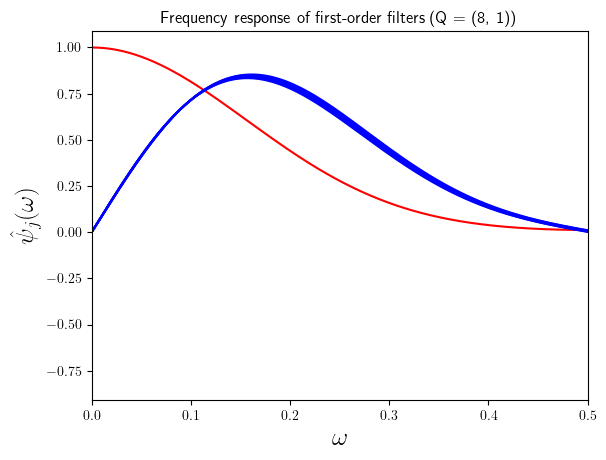

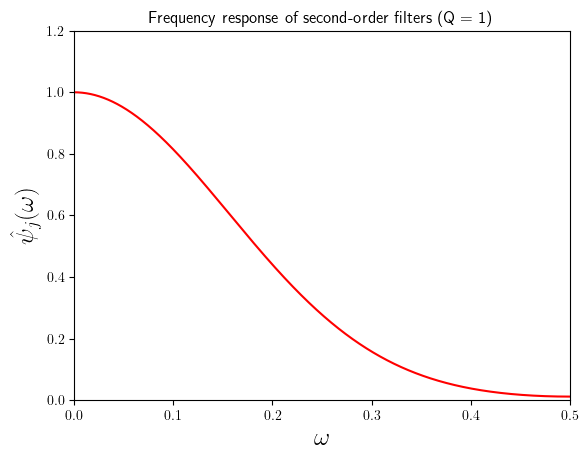

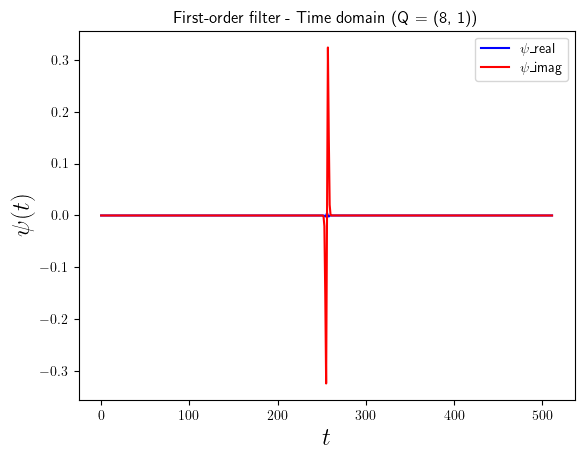

OK   (14.4s): examples/1d/plot_filters.py

RUNNING: examples/1d/plot_real_signal.py
FAIL (0.0s): examples/1d/plot_real_signal.py
Traceback (most recent call last):
  File "/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_53961/2786400997.py", line 10, in <module>
    runpy.run_path(f, run_name="__main__")
  File "<frozen runpy>", line 287, in run_path
  File "<frozen runpy>", line 98, in _run_module_code
  File "<frozen runpy>", line 88, in _run_code
  File "examples/1d/plot_real_signal.py", line 18, in <module>
    import librosa
ModuleNotFoundError: No module named 'librosa'


RUNNING: examples/1d/plot_synthetic.py


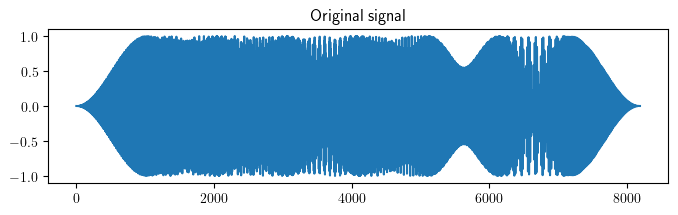

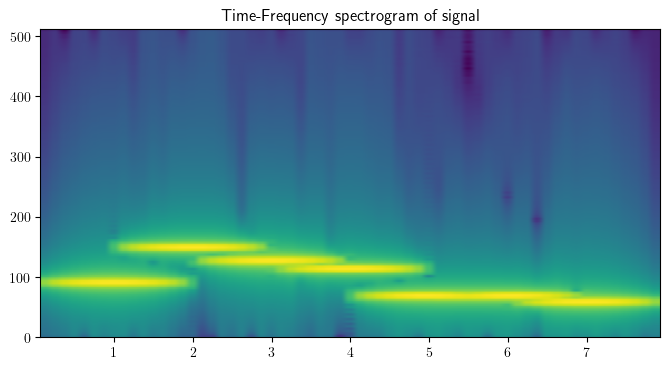

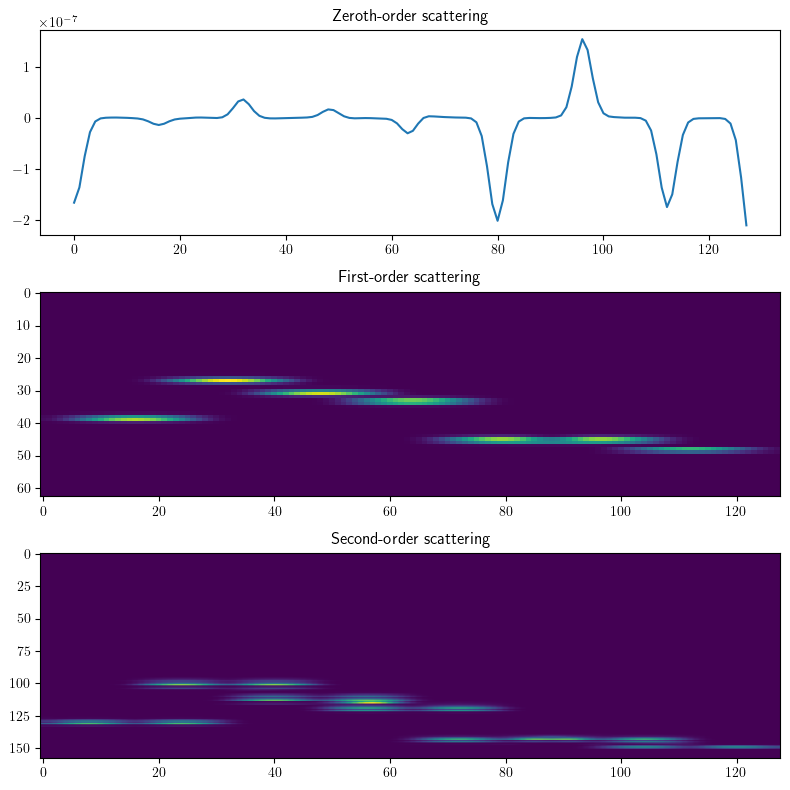

OK   (11.9s): examples/1d/plot_synthetic.py

RUNNING: examples/1d/reconstruct_torch.py
Iteration   0, loss 8.13
Iteration  10, loss 0.91
Iteration  20, loss 0.74
Iteration  30, loss 0.68
Iteration  40, loss 0.64
Iteration  50, loss 0.61
Iteration  60, loss 0.59
Iteration  70, loss 0.56
Iteration  80, loss 0.54
Iteration  90, loss 0.53
Iteration 100, loss 0.51
Iteration 110, loss 0.51
Iteration 120, loss 0.49
Iteration 130, loss 0.49
Iteration 140, loss 0.48
Iteration 150, loss 0.47
Iteration 160, loss 0.46
Iteration 170, loss 0.45
Iteration 180, loss 0.45
Iteration 190, loss 0.44


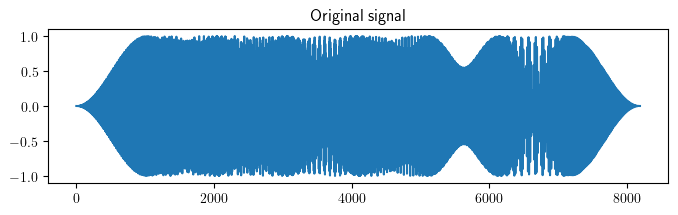

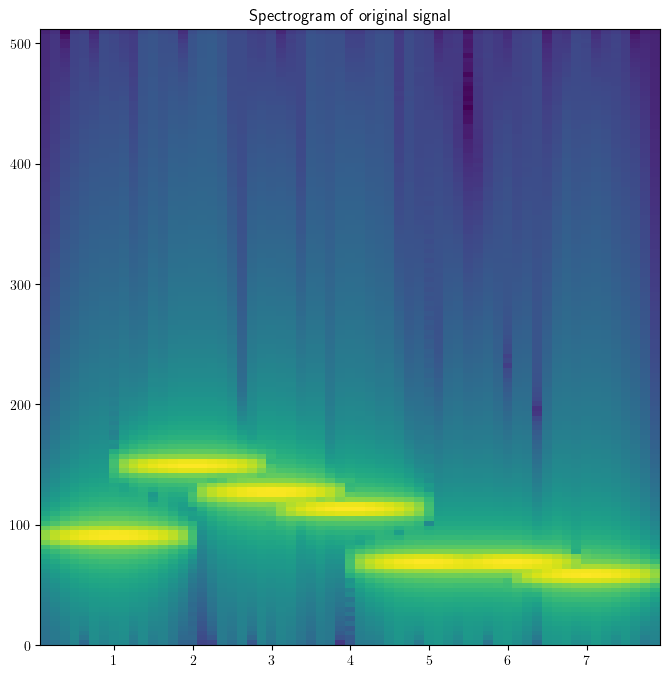

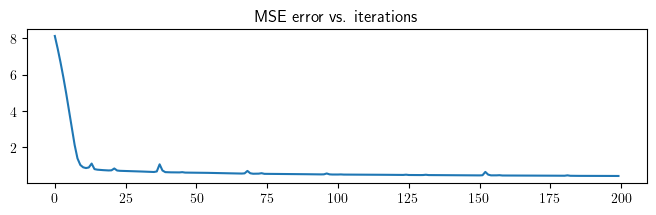

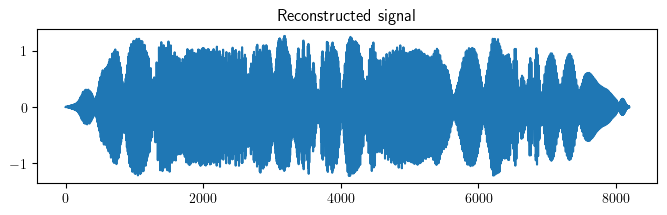

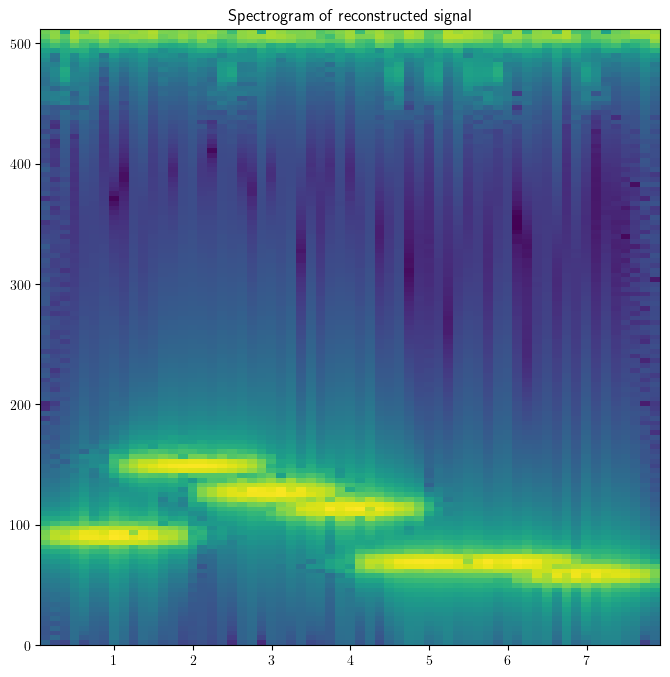

OK   (23.2s): examples/1d/reconstruct_torch.py

SUMMARY
OK      92.3s  examples/1d/classif_keras.py
FAIL     0.0s  examples/1d/plot_classif_torch.py
OK      14.4s  examples/1d/plot_filters.py
FAIL     0.0s  examples/1d/plot_real_signal.py
OK      11.9s  examples/1d/plot_synthetic.py
OK      23.2s  examples/1d/reconstruct_torch.py


In [16]:
import runpy, traceback, time, os

results = []
for f in files:
    print("\n" + "="*90)
    print("RUNNING:", f)
    t0 = time.time()
    try:
        # Run as a script (like `python file.py`) but inside the kernel
        runpy.run_path(f, run_name="__main__")
        dt = time.time() - t0
        print(f"OK   ({dt:.1f}s): {f}")
        results.append((f, "OK", dt, ""))
    except Exception as e:
        dt = time.time() - t0
        print(f"FAIL ({dt:.1f}s): {f}")
        tb = traceback.format_exc()
        print(tb)
        results.append((f, "FAIL", dt, tb))

print("\n" + "="*90)
print("SUMMARY")
for f, status, dt, _ in results:
    print(f"{status:4}  {dt:6.1f}s  {f}")

In [15]:
import os, shutil
print("PATH =", os.environ.get("PATH"))
print("latex =", shutil.which("latex"))
print("dvipng =", shutil.which("dvipng"))
print("gs =", shutil.which("gs"))

PATH = /Library/TeX/texbin:/Users/amasaryk/miniforge/envs/wavelet/bin:/Users/amasaryk/.gem/bin:/opt/homebrew/opt/ruby/bin:/Users/amasaryk/.local/bin:/opt/homebrew/bin:/opt/homebrew/sbin:/Users/amasaryk/miniforge/envs/wavelet/bin:/Users/amasaryk/miniforge/condabin:/Users/amasaryk/miniforge/bin:/opt/local/bin:/opt/local/sbin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/X11/bin:/Library/Apple/usr/bin:/Users/amasaryk/miniforge/envs/moose/wasp/bin
latex = /Library/TeX/texbin/latex
dvipng = /Library/TeX/texbin/dvipng
gs = /opt/homebrew/bin/gs


In [57]:
import os, shutil

texbin = "/Library/TeX/texbin"
os.environ["PATH"] = texbin + ":" + os.environ["PATH"]

print("latex =", shutil.which("latex"))
print("dvipng =", shutil.which("dvipng"))
print("gs =", shutil.which("gs"))

latex = /Library/TeX/texbin/latex
dvipng = /Library/TeX/texbin/dvipng
gs = /opt/homebrew/bin/gs


In [8]:
import site, os
pth_dir = site.getsitepackages()[0]
pth_path = os.path.join(pth_dir, "pyitd_local.pth")
repo_path = os.path.expanduser("~/projects/ssqueeze/PyITD")
with open(pth_path, "w") as f:
    f.write(repo_path + "\n")
print("Wrote:", pth_path)
print("Points to:", repo_path)

Wrote: /Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/pyitd_local.pth
Points to: /Users/amasaryk/projects/ssqueeze/PyITD


In [14]:
import ITD
print("ITD imported from:", ITD.__file__)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


ITD imported from: /Users/amasaryk/projects/ssqueeze/PyITD/ITD.py


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm.io import read_usgs_10min_file, create_signal, select_date_range

# --- Functions (notebook-specific) ---

# Function to check if a year is a leap year
def is_leap_year(year):
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)

# Function to plot signals cleanly
def plot_signals(signals, data, title='Creepmeter Displacement Signals', ylabel='Displacement (raw LVDT)', colors=None):
    plt.figure(figsize=(12, 8))
    
    # Default colors if not provided
    if colors is None:
        colors = ['black', 'blue', 'green', 'red', 'purple', 'orange', 'cyan', 'magenta']
    
    # Extract unique years
    years = sorted(data['Year'].astype(int).unique())
    year_ticks = []
    tick_labels = []
    
    for year in years:
        year_ticks.append(year)
        tick_labels.append(str(year))
    
    # Plot each signal
    for idx, (time, amplitude, label) in enumerate(signals):
        color = colors[idx % len(colors)]  # Loop over colors if needed
        plt.plot(time, amplitude, label=label, color=color, linewidth=1.5)
    
    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(year_ticks, tick_labels, rotation=45)
    plt.tight_layout()
    plt.show()

# --- Modified Main Code ---

# Path to your USGS .10min file
filename = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/xmr1.10min'
#filename = '/Users/amasaryk/projects/Creep/Creepmeters_Raw/Creep/raw/new/cwn1'
# Read the data
data = read_usgs_10min_file(filename)

# Select a specific date range (example: from day 100 of 2010 to day 200 of 2010)
start_date = '2011.8'  # Year 2010, Julian day 100
end_date = '2014.0'    # Year 2010, Julian day 200

# Filter data to selected range
selected_data = select_date_range(data, start_date, end_date)

# Create the signal from selected data
time, amplitude = create_signal(selected_data)

# Check for NaN or infinite values
print(f"Selected {len(selected_data)} data points from {start_date} to {end_date}")
print(f"NaN values in displacement data: {np.isnan(amplitude).sum()}")
print(f"Infinite values in displacement data: {np.isinf(amplitude).sum()}")

# Prepare signals for plotting
signals = [
    (time, amplitude, f'Selected Range ({start_date} to {end_date})'),
]

# Plot with the selected data for proper axis scaling
plot_signals(signals, selected_data, title='Creepmeter Displacement for Selected Date Range')


In [39]:
import numpy as np
import torch

def to_pow2(x: np.ndarray, mode="pad"):
    x = np.asarray(x, dtype=np.float32).copy()
    N = x.size
    N2 = 1 << (N - 1).bit_length()  # next power of 2
    if N2 == N:
        return x
    if mode == "pad":
        y = np.zeros(N2, dtype=np.float32)
        y[:N] = x
        return y
    elif mode == "crop":
        return x[: (1 << (N.bit_length() - 1))]
    else:
        raise ValueError("mode must be 'pad' or 'crop'")

# amplitude = your displacement array (1D)
# amplitude = amplitude - np.nanmean(amplitude)
# amplitude = np.nan_to_num(amplitude, nan=0.0, posinf=0.0, neginf=0.0)

x_np = amplitude.astype(np.float32)
x_np = x_np - np.mean(x_np)
x_np = to_pow2(x_np, mode="crop")

In [51]:
from kymatio.torch import Scattering1D

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

N = x_np.size
J = 4   # start here; increase if you want more large-scale averaging
Q = 8    # wavelets per octave (typical 8 or 16)

sc = Scattering1D(J=J, shape=N, Q=Q).to(device)

x = torch.from_numpy(x_np)[None, :]  # (batch=1, N)
x = x.to(device)

Sx = sc(x)  # (1, C, T')
Sx_cpu = Sx.detach().cpu().numpy()[0]  # (C, T')

In [52]:
meta = sc.meta()
order = meta["order"]          # (C,)
j = meta["j"]                  # (C, max_order) entries, -1 for unused

idx1 = np.where(order == 1)[0]             # first-order channels
S1 = Sx_cpu[idx1, :]                       # (C1, T')
j1 = j[idx1, 0]                            # the scale index for order-1
sort = np.argsort(j1)
S1 = S1[sort, :]
j1 = j1[sort]

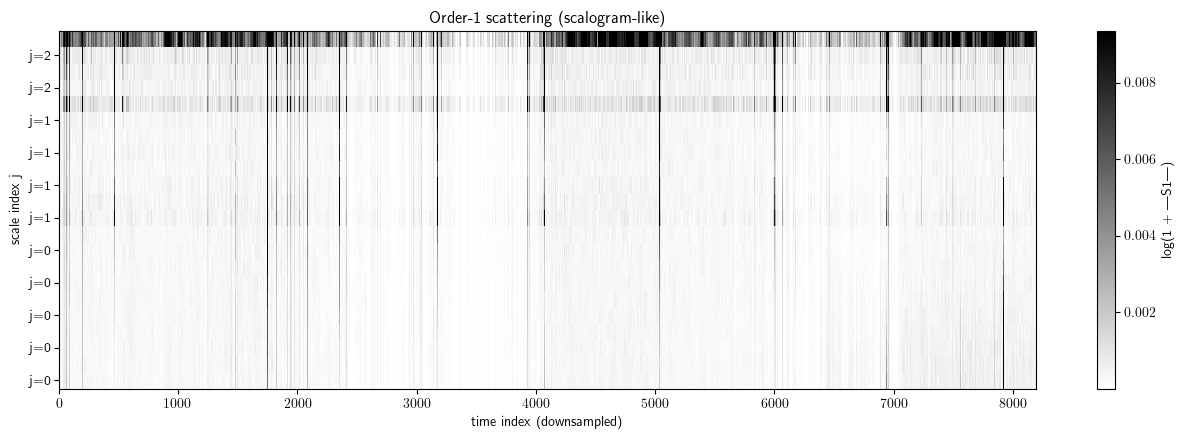

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# S1: (n_scales, T) order-1 scattering (already sorted by j1)
A = np.log1p(np.abs(S1))

# Robust contrast: clip to 1–99th percentiles
vmin, vmax = np.percentile(A, [1, 99])

plt.figure(figsize=(13, 4.5))
plt.imshow(
    A,
    aspect="auto",
    origin="lower",
    cmap="binary",          # white↔black ramp
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
)
plt.xlabel("time index (downsampled)")
plt.ylabel("scale index j")
plt.title("Order-1 scattering (scalogram-like)")

# fewer y ticks so it’s readable
step = max(1, len(j1)//10)
plt.yticks(
    ticks=np.arange(0, len(j1), step),
    labels=[f"j={int(v)}" for v in j1[::step]],
)

cbar = plt.colorbar()
cbar.set_label("log(1 + |S1|)")
plt.tight_layout()
plt.show()

In [27]:
import kymatio.torch as kt
[n for n in dir(kt) if "Time" in n or "Frequency" in n or "JTFS" in n]

['TimeFrequencyScattering']

In [28]:
from kymatio.torch import TimeFrequencyScattering

In [54]:
import numpy as np

A = np.log1p(np.abs(S1)).astype(np.float64)   # (n_scales, T)
A -= A.mean(axis=1, keepdims=True)            # center each scale channel

U, s, Vt = np.linalg.svd(A, full_matrices=False)

# k dominant modes
k = 5
modes_time = Vt[:k, :]          # (k, T)  <-- mode time series (what you probably want)
modes_scale = U[:, :k]          # (n_scales, k) <-- scale loadings
singvals = s[:k]

print("Top singular values:", singvals)

Top singular values: [1.53492281 0.14966752 0.08950277 0.07474504 0.03056454]


In [59]:
import matplotlib as mpl, shutil, os
print("usetex =", mpl.rcParams.get("text.usetex"))
print("latex on PATH? ->", shutil.which("latex"))
print("dvipng on PATH? ->", shutil.which("dvipng"))
print("gs on PATH? ->", shutil.which("gs"))

usetex = True
latex on PATH? -> /Library/TeX/texbin/latex
dvipng on PATH? -> /Library/TeX/texbin/dvipng
gs on PATH? -> /opt/homebrew/bin/gs


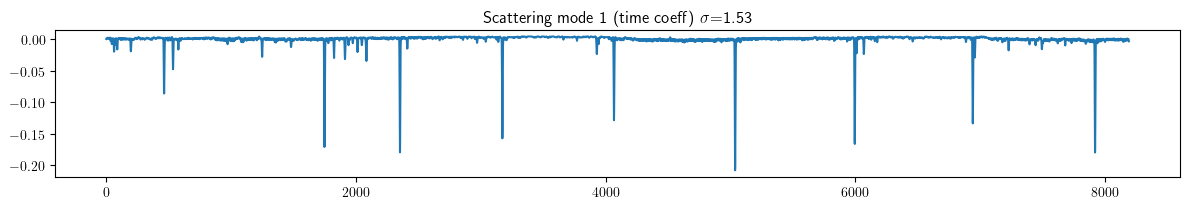

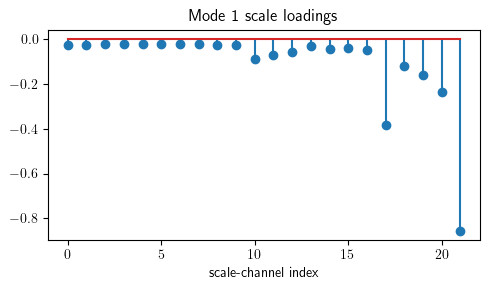

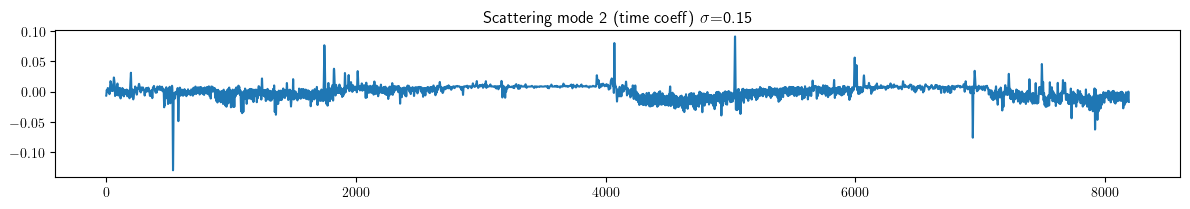

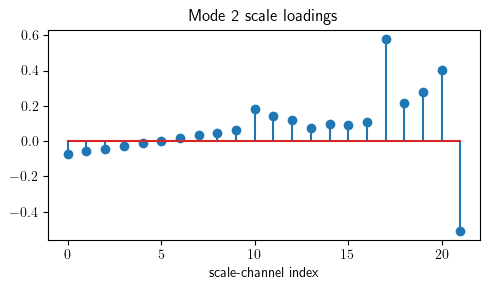

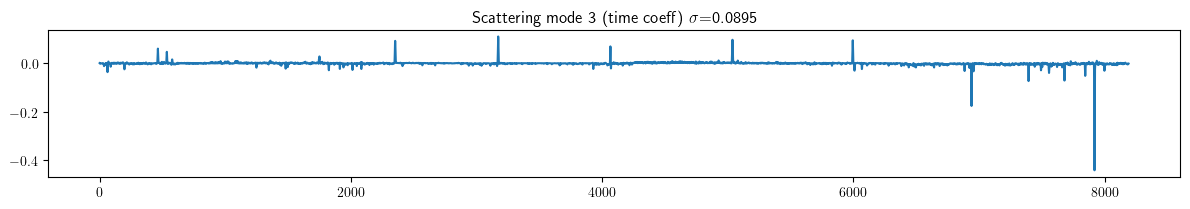

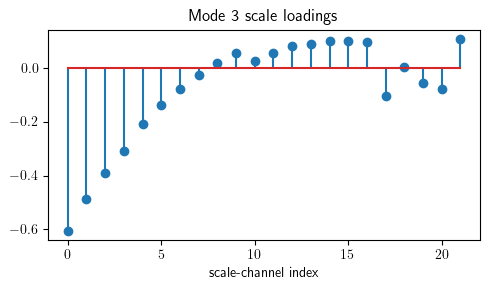

In [64]:
import matplotlib.pyplot as plt

for i in range(3):
    # time coefficient
    plt.figure(figsize=(12, 2.2))
    plt.plot(modes_time[i])
    plt.title(rf"Scattering mode {i+1} (time coeff)  $\sigma$={singvals[i]:.3g}")
    plt.tight_layout()
    plt.show()

    # scale loadings
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.stem(modes_scale[:, i])
    ax.set_title(f"Mode {i+1} scale loadings")
    ax.set_xlabel("scale-channel index")
    fig.tight_layout()
    plt.show()

In [66]:
import numpy as np

meta = sc.meta()
order = meta["order"]
j = meta["j"]

idx1 = np.where(order == 1)[0]
j1 = j[idx1, 0].astype(int)          # j index for each order-1 channel

# If you sorted S1 by j before: apply the same sort here
sort = np.argsort(j1)
j1_sorted = j1[sort]

print("j1_sorted:", j1_sorted)
print("S1 shape:", S1.shape, "j1_sorted len:", len(j1_sorted))

j1_sorted: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 2 2 2 2 3]
S1 shape: (22, 8192) j1_sorted len: 22


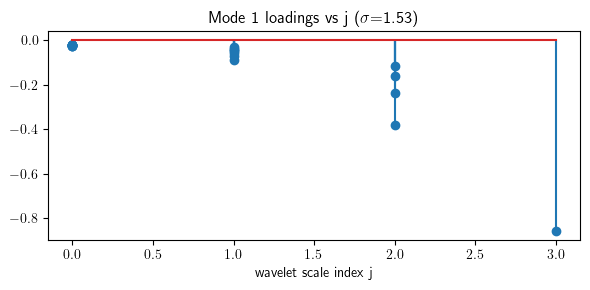

In [67]:
import matplotlib.pyplot as plt

i = 0
plt.figure(figsize=(6,3))
plt.stem(j1_sorted, modes_scale[:, i])
plt.xlabel("wavelet scale index j")
plt.title(rf"Mode {i+1} loadings vs j  ($\sigma$={singvals[i]:.3g})")
plt.tight_layout()
plt.show()

In [56]:
from sklearn.decomposition import NMF

A = np.log1p(np.abs(S1))
A = np.maximum(A, 0)

nmf = NMF(n_components=4, init="nndsvda", max_iter=2000, random_state=0)
W = nmf.fit_transform(A)     # (n_scales, r)  scale patterns
H = nmf.components_          # (r, T)         time activations

# H rows are your “mode activation time series”

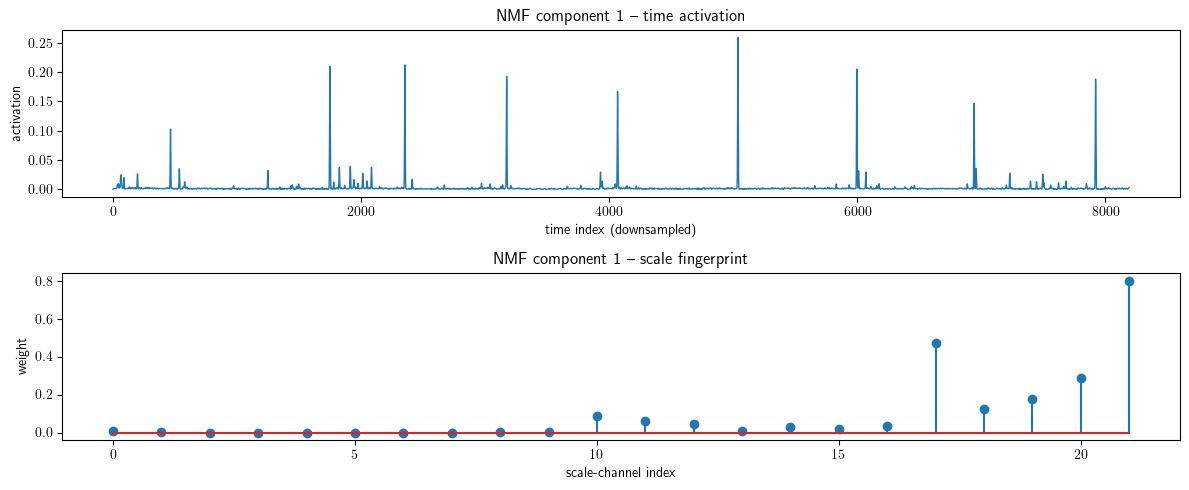

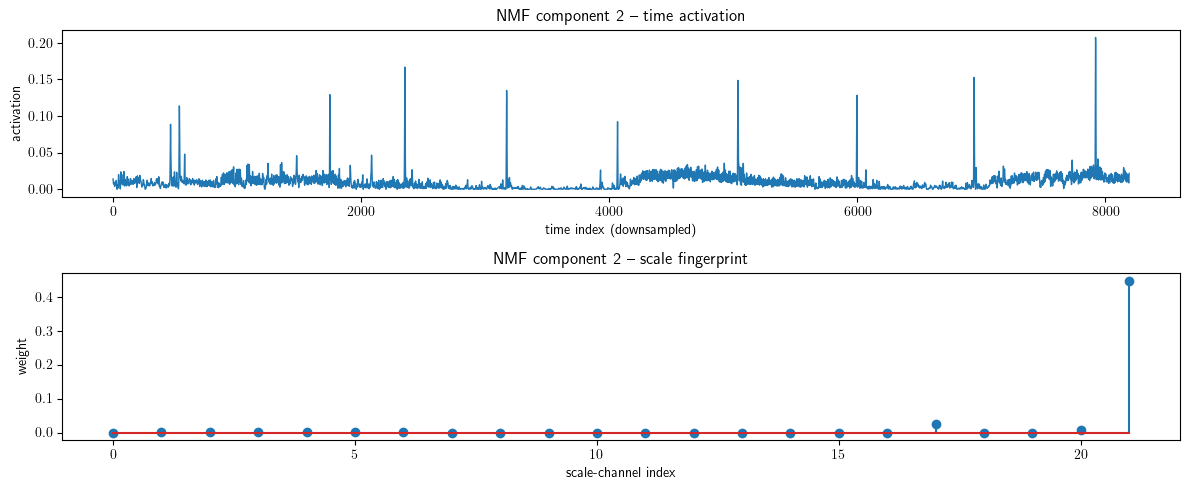

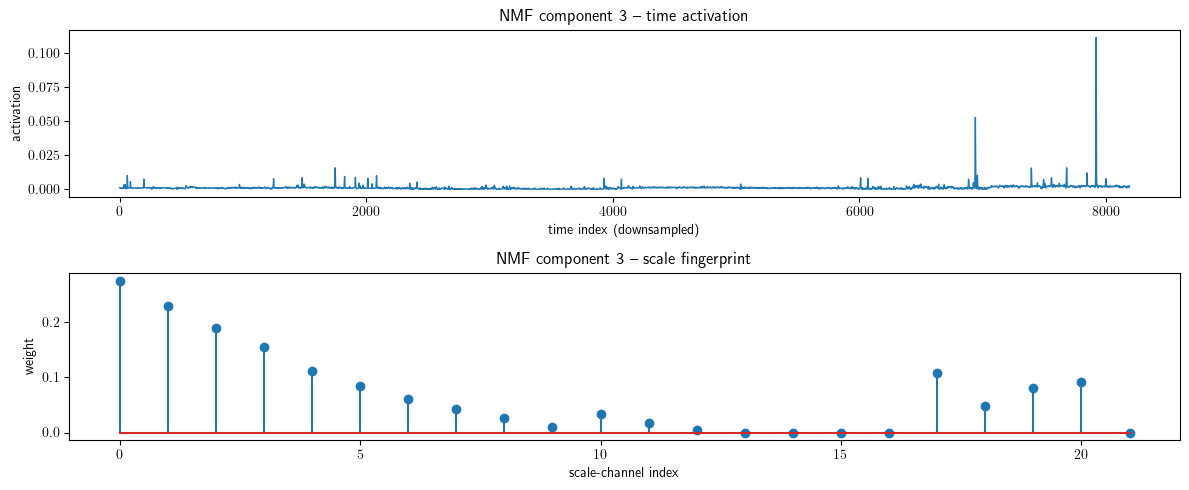

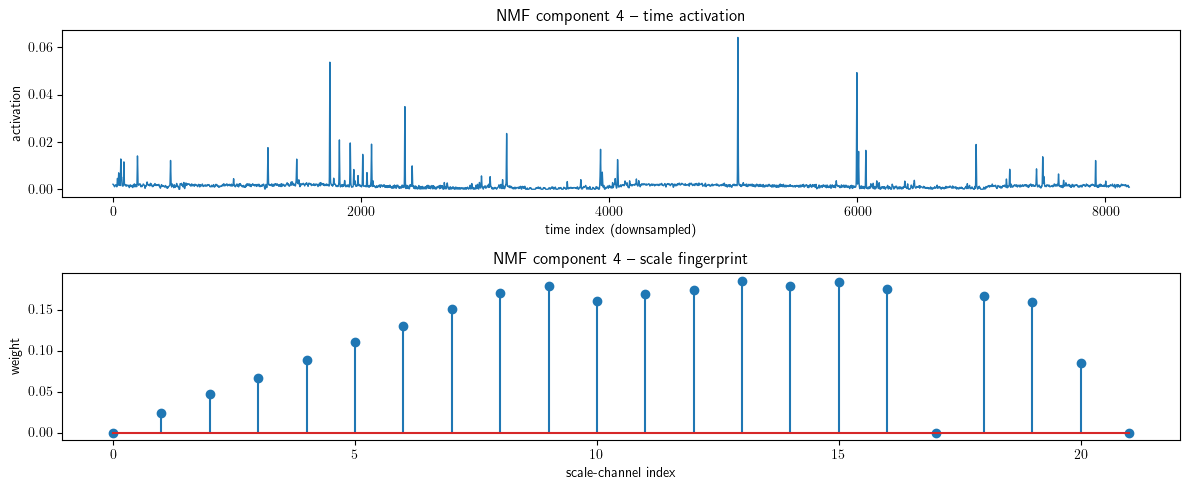

In [68]:
import numpy as np
import matplotlib.pyplot as plt

r = H.shape[0]

for k in range(r):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

    # Time activation
    ax1.plot(H[k], linewidth=1)
    ax1.set_title(f"NMF component {k+1} – time activation")
    ax1.set_xlabel("time index (downsampled)")
    ax1.set_ylabel("activation")

    # Scale fingerprint
    ax2.stem(W[:, k])
    ax2.set_title(f"NMF component {k+1} – scale fingerprint")
    ax2.set_xlabel("scale-channel index")
    ax2.set_ylabel("weight")

    fig.tight_layout()
    plt.show()

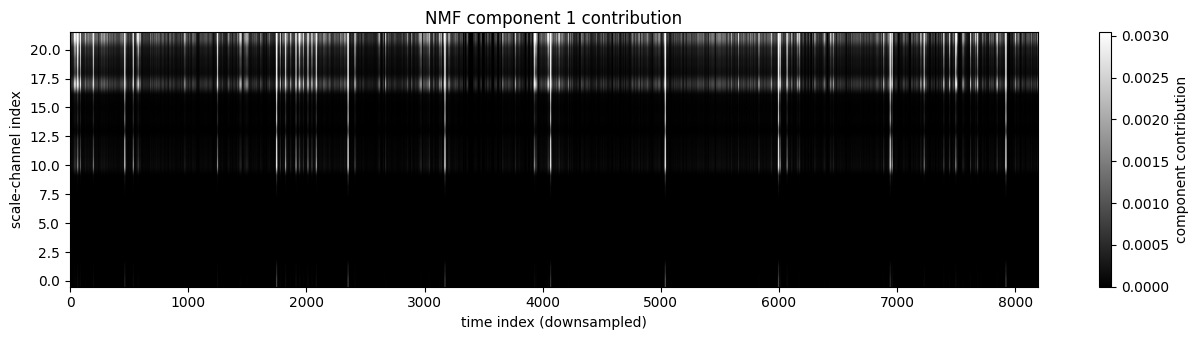

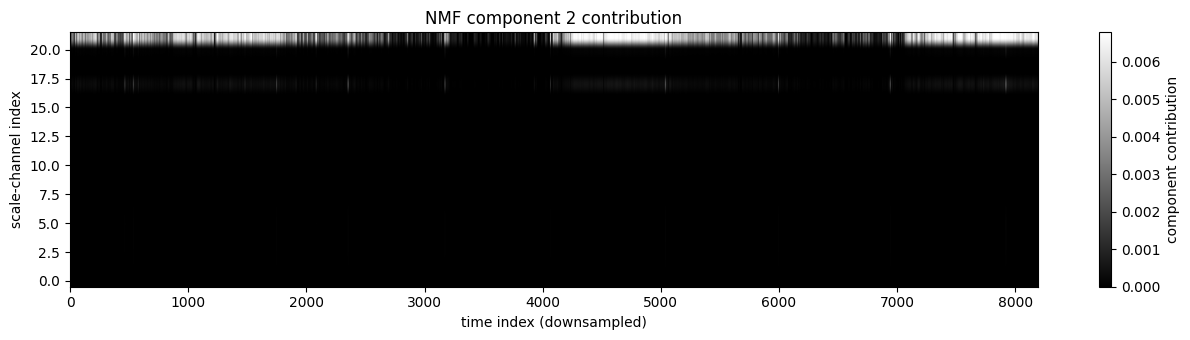

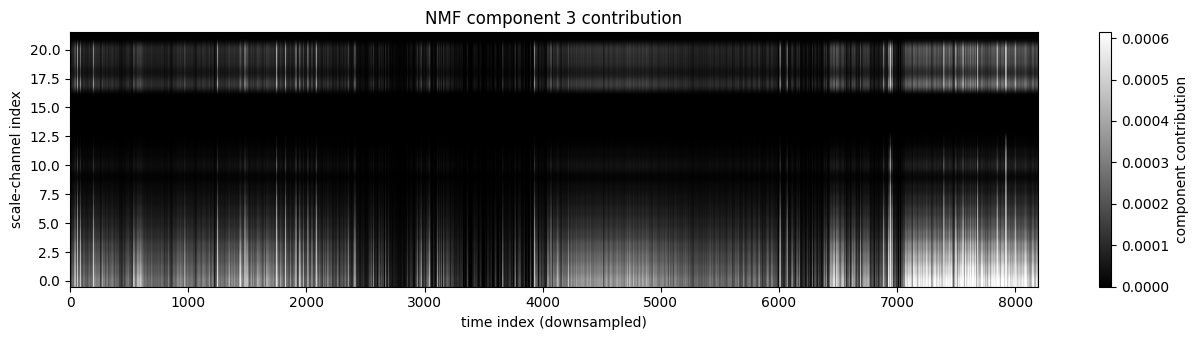

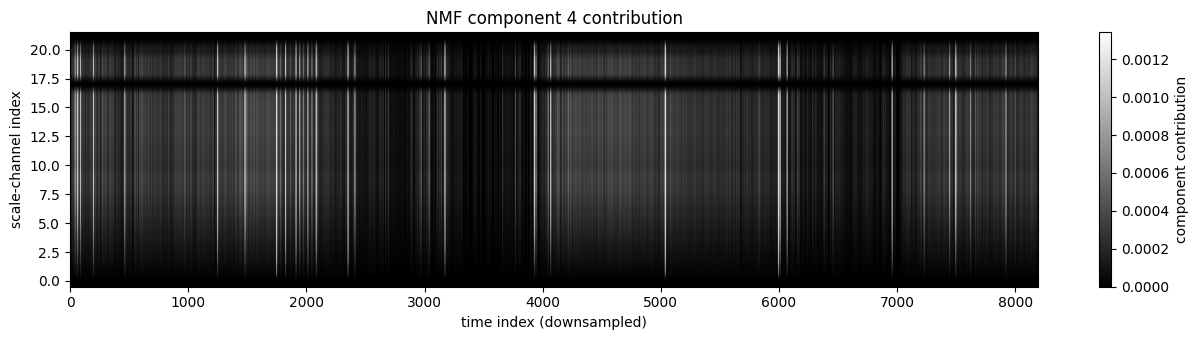

In [72]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

old = mpl.rcParams["text.usetex"]
mpl.rcParams["text.usetex"] = False  # keep OFF during these plots

for k in range(r):
    Ak = np.outer(W[:, k], H[k, :])

    vmin, vmax = np.percentile(Ak, [1, 99])
    plt.figure(figsize=(13, 3.5))
    plt.imshow(Ak, aspect="auto", origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    plt.colorbar(label="component contribution")
    plt.title(f"NMF component {k+1} contribution")
    plt.xlabel("time index (downsampled)")
    plt.ylabel("scale-channel index")
    plt.tight_layout()
    plt.show()

mpl.rcParams["text.usetex"] = old  # restore AFTER all plots

In [70]:
import os, glob
print("cwd:", os.getcwd())
print("logs:", glob.glob("*.log")[:10])

cwd: /Users/amasaryk/projects/ssqueeze/kymatio
logs: []


In [73]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from kymatio.torch import Scattering1D

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# --- 1) Prepare your amplitude signal ---
# amplitude: 1D numpy array from your creepmeter selection
x_np = amplitude.astype(np.float32)
x_np = np.nan_to_num(x_np, nan=0.0, posinf=0.0, neginf=0.0)

# Optional: remove mean + scale (helps optimization a lot)
x_np = x_np - x_np.mean()
x_np = x_np / (x_np.std() + 1e-8)

T = x_np.size

# Kymatio expects (batch, T) for Scattering1D in torch
x = torch.from_numpy(x_np)[None, :].to(device)



In [ ]:
# --- 2) Scattering transform of target signal ---
J = 10   # for creep data you probably want bigger than 6; start 8–12
Q = 8    # 8 or 16; 16 is finer but heavier

scattering = Scattering1D(J=J, shape=T, Q=Q, order=2).to(device)

with torch.no_grad():
    Sx = scattering(x)  # (1, C, T')


In [77]:

# --- 3) Reconstruct: optimize y so scattering(y) matches scattering(x) ---
torch.manual_seed(0)
y = torch.randn((1, T), device=device, requires_grad=True)

learning_rate = 1.0
bold_driver_accelerator = 1.05
bold_driver_brake = 0.5
n_iterations = 200

history = []
prev_loss = None

for k in range(n_iterations):
    Sy = scattering(y)
    loss = torch.norm(Sx - Sy)

    if k % 10 == 0:
        print(f"Iter {k:4d} | loss {loss.item():.6f} | lr {learning_rate:.3g}")

    history.append(loss.detach().cpu().item())

    # backprop
    loss.backward()

    with torch.no_grad():
        grad = y.grad
        y_new = y - learning_rate * grad
        y.grad.zero_()  # IMPORTANT: clear grads

    # bold driver LR update
    if prev_loss is not None and history[-1] > prev_loss:
        learning_rate *= bold_driver_brake
    else:
        learning_rate *= bold_driver_accelerator
        y = y_new.detach().requires_grad_(True)

    prev_loss = history[-1]

y_rec = y.detach().cpu().numpy()[0]


Iter    0 | loss 14.651759 | lr 1
Iter   10 | loss 14.648675 | lr 1.63
Iter   20 | loss 14.643661 | lr 2.65
Iter   30 | loss 14.635511 | lr 4.32
Iter   40 | loss 14.622290 | lr 7.04
Iter   50 | loss 14.600893 | lr 11.5
Iter   60 | loss 14.566404 | lr 18.7
Iter   70 | loss 14.511195 | lr 30.4
Iter   80 | loss 14.423799 | lr 49.6
Iter   90 | loss 14.288023 | lr 80.7
Iter  100 | loss 14.083699 | lr 132
Iter  110 | loss 13.792622 | lr 214
Iter  120 | loss 13.415904 | lr 349
Iter  130 | loss 13.003734 | lr 568
Iter  140 | loss 12.663346 | lr 926
Iter  150 | loss 12.477018 | lr 1.51e+03
Iter  160 | loss 12.412015 | lr 2.46e+03
Iter  170 | loss 12.397696 | lr 4e+03
Iter  180 | loss 12.395496 | lr 6.52e+03
Iter  190 | loss 12.394433 | lr 2.41e+03


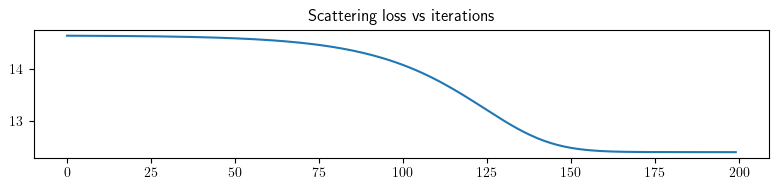

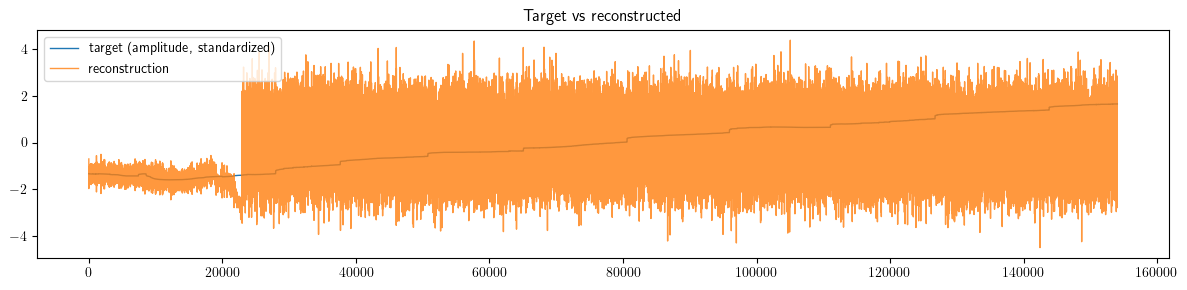

In [78]:

# --- 4) Plot results ---
plt.figure(figsize=(8, 2))
plt.plot(history)
plt.title("Scattering loss vs iterations")
plt.tight_layout()

plt.figure(figsize=(12, 3))
plt.plot(x_np, label="target (amplitude, standardized)", linewidth=1)
plt.plot(y_rec, label="reconstruction", linewidth=1, alpha=0.8)
plt.legend()
plt.title("Target vs reconstructed")
plt.tight_layout()

plt.show()

ValueError: x and y must have same first dimension, but have shapes (154031,) and (3,)

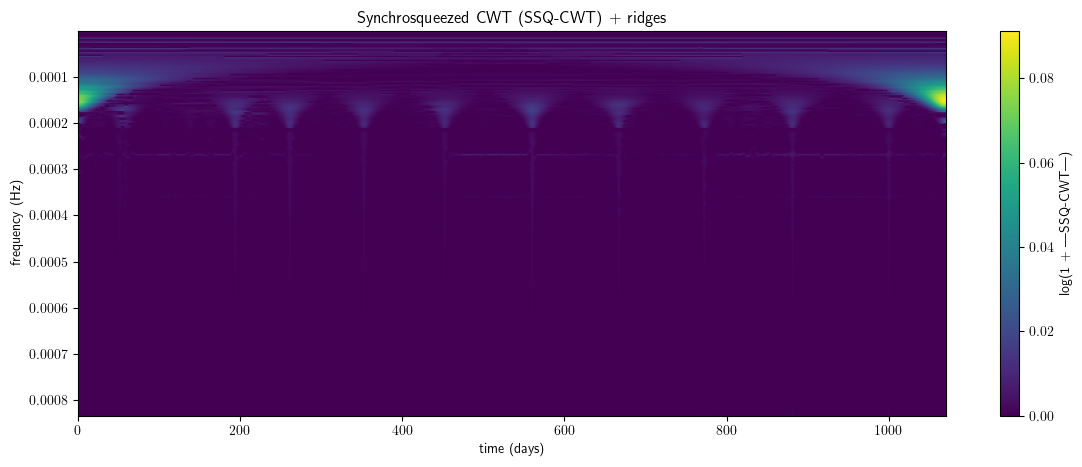

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import ssq_cwt, extract_ridges

# ---- input ----
x = amplitude.astype(np.float64)
x = np.nan_to_num(x, nan=np.nanmean(x))
x = x - np.mean(x)

# sampling: 10 minutes per sample
dt = 10 * 60        # seconds
fs = 1 / dt         # Hz

# ---- optional: remove very slow drift so ridges track oscillations ----
# (doesn't smooth steps much; it just removes a moving-average trend)
def moving_average(a, w):
    w = int(w)
    if w < 3:
        return a
    kernel = np.ones(w) / w
    return np.convolve(a, kernel, mode="same")

trend_days = 7  # try 3–14 days
w = int((trend_days * 86400) / dt)
x_osc = x - moving_average(x, w)

# ---- synchrosqueezing ----
Tx, Wx, ssq_freqs, scales = ssq_cwt(x_osc, wavelet="morlet", fs=fs)

A = np.abs(Tx)  # (n_freq, n_time)

# ---- ridge extraction (pick a few ridges) ----
# penalty: higher => smoother ridges; n_ridges: how many tracks
ridges = extract_ridges(A, ssq_freqs, penalty=2.0, n_ridges=3)

# ---- plot ----
t_days = np.arange(x.size) * dt / 86400.0

plt.figure(figsize=(14, 5))
# show in log scale so weak bands show up
plt.imshow(np.log1p(A), aspect="auto", origin="lower",
           extent=[t_days[0], t_days[-1], ssq_freqs[0], ssq_freqs[-1]])
plt.colorbar(label="log(1 + |SSQ-CWT|)")
plt.xlabel("time (days)")
plt.ylabel("frequency (Hz)")
plt.title("Synchrosqueezed CWT (SSQ-CWT) + ridges")

for r in ridges:
    f_r = ssq_freqs[r]
    plt.plot(t_days, f_r, linewidth=2)

plt.tight_layout()
plt.show()

In [80]:
import numpy as np

R = np.asarray(ridges)
print("ridges shape:", R.shape)  # helpful

# If ridges returned as (n_ridges, n_time), transpose for easy plotting
if R.ndim == 2 and R.shape[0] < R.shape[1]:
    # assume (n_ridges, n_time)
    ridx = R
elif R.ndim == 2:
    # assume (n_time, n_ridges)
    ridx = R.T
else:
    # single ridge as 1D
    ridx = R[None, :]

ridges shape: (154031, 3)


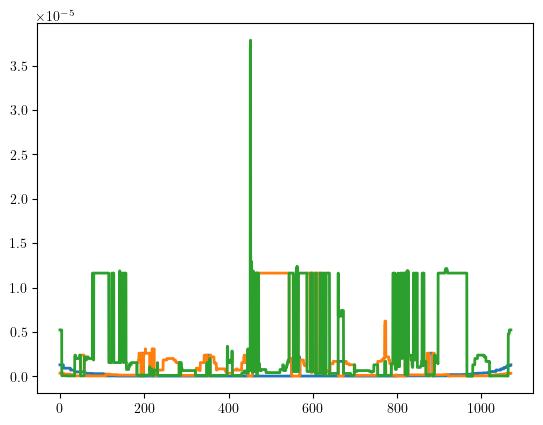

In [81]:
for k in range(ridx.shape[0]):
    f_r = ssq_freqs[ridx[k].astype(int)]   # (n_time,)
    plt.plot(t_days, f_r, linewidth=2)

Text(0, 0.5, 'frequency (cycles/day)')

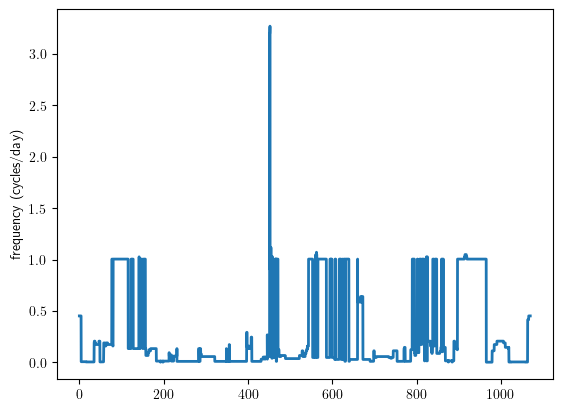

In [82]:
freq_cpd = ssq_freqs * 86400.0
# When plotting ridges:
f_r_cpd = freq_cpd[ridx[k].astype(int)]
plt.plot(t_days, f_r_cpd, linewidth=2)
plt.ylabel("frequency (cycles/day)")

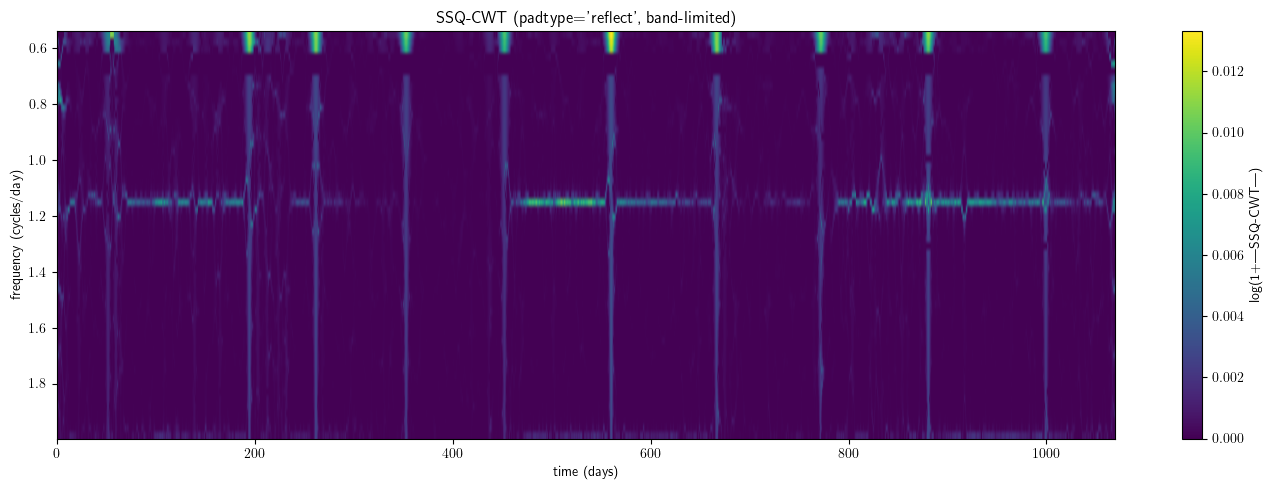

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import ssq_cwt

dt = 10*60
fs = 1/dt
t_days = np.arange(len(x_osc)) * dt / 86400

Tx, Wx, ssq_freqs, scales = ssq_cwt(x_osc, wavelet="morlet", fs=fs, padtype="reflect")
A = np.abs(Tx)

freq_cpd = ssq_freqs * 86400
band = (freq_cpd >= 0.5) & (freq_cpd <= 2.0)

plt.figure(figsize=(14,5))
plt.imshow(np.log1p(A[band]), aspect="auto", origin="lower",
           extent=[t_days[0], t_days[-1], freq_cpd[band][0], freq_cpd[band][-1]])
plt.xlabel("time (days)")
plt.ylabel("frequency (cycles/day)")
plt.title("SSQ-CWT (padtype='reflect', band-limited)")
plt.colorbar(label="log(1+|SSQ-CWT|)")
plt.tight_layout()
plt.show()